# 1. Evaluation w/ Mask Decoder
## Single Image Check

Loading checkpoint from exp/xray-0306/latest.pth...
Loaded checkpoint from epoch 29
Best metrics so far: {'d1': 0.9973202347755432, 'd2': 0.9999925494194031, 'd3': 1.0, 'abs_rel': 0.052153825759887695, 'sq_rel': 2.1573922634124756, 'rmse': 28.07469367980957, 'rmse_log': 0.0557907298207283, 'log10': 0.02256508357822895, 'silog': 0.04244745522737503}
Image: mean=0.6260  min=0.0000  max=1.0000
Depth pred — min=439.746  max=790.879  mean=555.026
Mask pred  — min=0.000  max=1.000  mean=0.649
GT depth   — min=436.100  max=754.200  valid px: 382871 / 589824


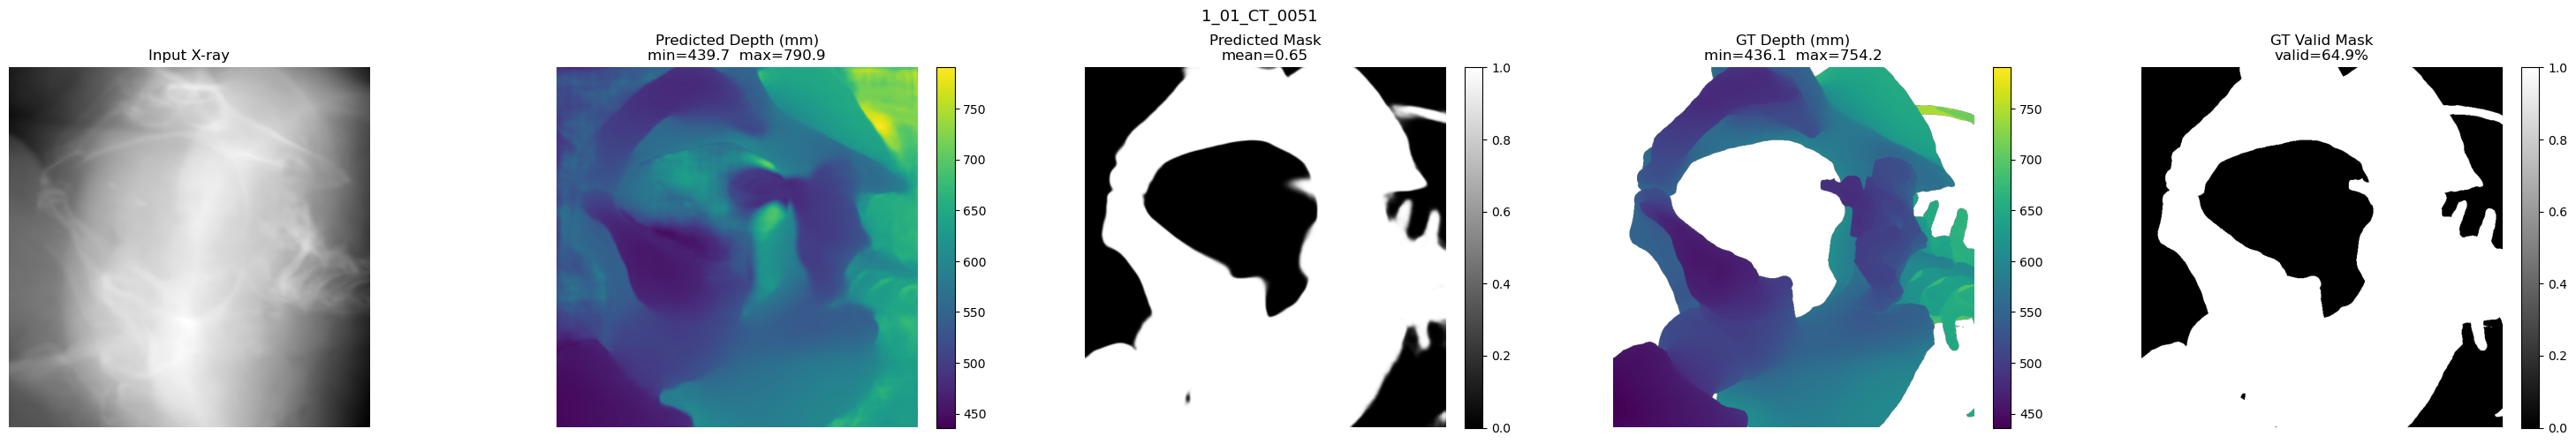

Saved to eval_result.png


In [5]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.transforms import Compose
import os

from depth_anything_v2.dpt import DepthAnythingV2
from dataset.transform import Resize, NormalizeImage, PrepareForNet

# ── Config ────────────────────────────────────────────────────────────────────
ENCODER        = "vitl"
CHECKPOINT     = "exp/xray-0306/latest.pth"
IMAGE_DIR      = "/home/jeremy/data/XrayDepthEstScaling/images"
DEPTH_DIR      = "/home/jeremy/data/XrayDepthEstScaling/depths"
FILENAME       = "1_01_CT_0051"   # stem only, no extension
MAX_DEPTH      = 1000.0
IMG_SIZE       = 518

model_configs = {
    "vits": {"encoder": "vits", "features": 64,  "out_channels": [48, 96, 192, 384]},
    "vitb": {"encoder": "vitb", "features": 128, "out_channels": [96, 192, 384, 768]},
    "vitl": {"encoder": "vitl", "features": 256, "out_channels": [256, 512, 1024, 1024]},
}

# ── Model ─────────────────────────────────────────────────────────────────────
model = DepthAnythingV2(**{**model_configs[ENCODER], "max_depth": MAX_DEPTH, "predict_mask": True})

if os.path.exists(CHECKPOINT):
    print(f"Loading checkpoint from {CHECKPOINT}...")
    checkpoint = torch.load(CHECKPOINT, map_location="cpu")
    model.load_state_dict(checkpoint["model"])
    print(f"Loaded checkpoint from epoch {checkpoint.get('epoch', '?')}")
    print(f"Best metrics so far: {checkpoint.get('previous_best', 'N/A')}")
else:
    print(f"Warning: checkpoint not found at {CHECKPOINT}. Proceeding with random weights.")

model = model.cuda().eval()

# ── Transform ─────────────────────────────────────────────────────────────────
transform = Compose([
    Resize(
        width=IMG_SIZE,
        height=IMG_SIZE,
        resize_target=False,
        keep_aspect_ratio=True,
        ensure_multiple_of=14,
        resize_method="lower_bound",
        image_interpolation_method=cv2.INTER_CUBIC,
    ),
    NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    PrepareForNet(),
])

# ── Load & preprocess image ───────────────────────────────────────────────────
image_path = os.path.join(IMAGE_DIR, FILENAME + ".tif")
depth_path = os.path.join(DEPTH_DIR, FILENAME + ".tif")

raw_image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
assert raw_image is not None, f"Could not read image: {image_path}"
assert raw_image.dtype == np.float32, f"Expected float32 TIFF, got {raw_image.dtype}"
print(f"Image: mean={raw_image.mean():.4f}  min={raw_image.min():.4f}  max={raw_image.max():.4f}")

image_3ch = np.stack([raw_image, raw_image, raw_image], axis=-1).astype(np.float32)
sample = transform({"image": image_3ch, "depth": np.zeros_like(raw_image)})
img_tensor = torch.from_numpy(sample["image"]).unsqueeze(0).cuda()

# ── Inference ─────────────────────────────────────────────────────────────────
with torch.no_grad():
    pred, pred_mask = model(img_tensor)

orig_h, orig_w = raw_image.shape
pred = F.interpolate(pred[:, None], (orig_h, orig_w), mode="bilinear", align_corners=True)[0, 0].cpu().numpy()
pred_mask = F.interpolate(pred_mask[:, None], (orig_h, orig_w), mode="bilinear", align_corners=True)[0, 0].cpu().numpy()

print(f"Depth pred — min={pred.min():.3f}  max={pred.max():.3f}  mean={pred.mean():.3f}")
print(f"Mask pred  — min={pred_mask.min():.3f}  max={pred_mask.max():.3f}  mean={pred_mask.mean():.3f}")

# ── Load GT depth ─────────────────────────────────────────────────────────────
gt_depth, valid = None, None
if os.path.exists(depth_path):
    gt_raw = cv2.imread(depth_path, cv2.IMREAD_ANYCOLOR | cv2.IMREAD_ANYDEPTH)
    gt_depth = gt_raw.astype(np.float32) / 10.0  # uint16 → mm
    valid = (gt_depth > 0) & (gt_depth <= MAX_DEPTH)
    print(f"GT depth   — min={gt_depth[valid].min():.3f}  max={gt_depth[valid].max():.3f}  "
          f"valid px: {valid.sum()} / {valid.size}")

# ── Visualise ─────────────────────────────────────────────────────────────────
depth_unit = "mm" if MAX_DEPTH > 100 else "m"
has_gt = gt_depth is not None
ncols = 5 if has_gt else 3

fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))
fig.suptitle(FILENAME, fontsize=13)

vmin, vmax = pred.min(), pred.max()
if has_gt:
    vmin = min(vmin, gt_depth[valid].min())
    vmax = max(vmax, gt_depth[valid].max())

# Col 0: input
axes[0].imshow(raw_image, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Input X-ray")
axes[0].axis("off")

# Col 1: predicted depth
im1 = axes[1].imshow(pred, cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title(f"Predicted Depth ({depth_unit})\nmin={pred.min():.1f}  max={pred.max():.1f}")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Col 2: predicted mask
im2 = axes[2].imshow(pred_mask, cmap="gray", vmin=0, vmax=1)
axes[2].set_title(f"Predicted Mask\nmean={pred_mask.mean():.2f}")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

if has_gt:
    # Col 3: GT depth
    gt_vis = np.where(valid, gt_depth, np.nan)
    im3 = axes[3].imshow(gt_vis, cmap="viridis", vmin=vmin, vmax=vmax)
    axes[3].set_title(f"GT Depth ({depth_unit})\nmin={gt_depth[valid].min():.1f}  max={gt_depth[valid].max():.1f}")
    axes[3].axis("off")
    plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

    # Col 4: GT valid mask
    im4 = axes[4].imshow(valid.astype(np.float32), cmap="gray", vmin=0, vmax=1)
    axes[4].set_title(f"GT Valid Mask\nvalid={valid.mean()*100:.1f}%")
    axes[4].axis("off")
    plt.colorbar(im4, ax=axes[4], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("eval_result.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to eval_result.png")

## Random Validation Set Images

Loading checkpoint from exp/xray-0306/latest.pth...
Loaded epoch 29 | best metrics: {'d1': 0.9973202347755432, 'd2': 0.9999925494194031, 'd3': 1.0, 'abs_rel': 0.052153825759887695, 'sq_rel': 2.1573922634124756, 'rmse': 28.07469367980957, 'rmse_log': 0.0557907298207283, 'log10': 0.02256508357822895, 'silog': 0.04244745522737503}
Showing 5 / 2200 validation samples
[1/5] 2_04_CT_0019.tif — pred [411.5, 701.7] | gt [406.4, 716.6] | abs_err mean=7.9mm
[2/5] 1_02_CT_0242.tif — pred [372.3, 590.2] | gt [431.5, 687.1] | abs_err mean=56.3mm
[3/5] Pelvic-Ref-005_0192.tif — pred [385.5, 744.7] | gt [394.9, 704.4] | abs_err mean=11.5mm
[4/5] Pelvic-Ref-002_0233.tif — pred [340.8, 524.9] | gt [333.9, 557.6] | abs_err mean=28.6mm
[5/5] 3_04_CT_0215.tif — pred [453.1, 675.8] | gt [426.4, 643.2] | abs_err mean=29.9mm


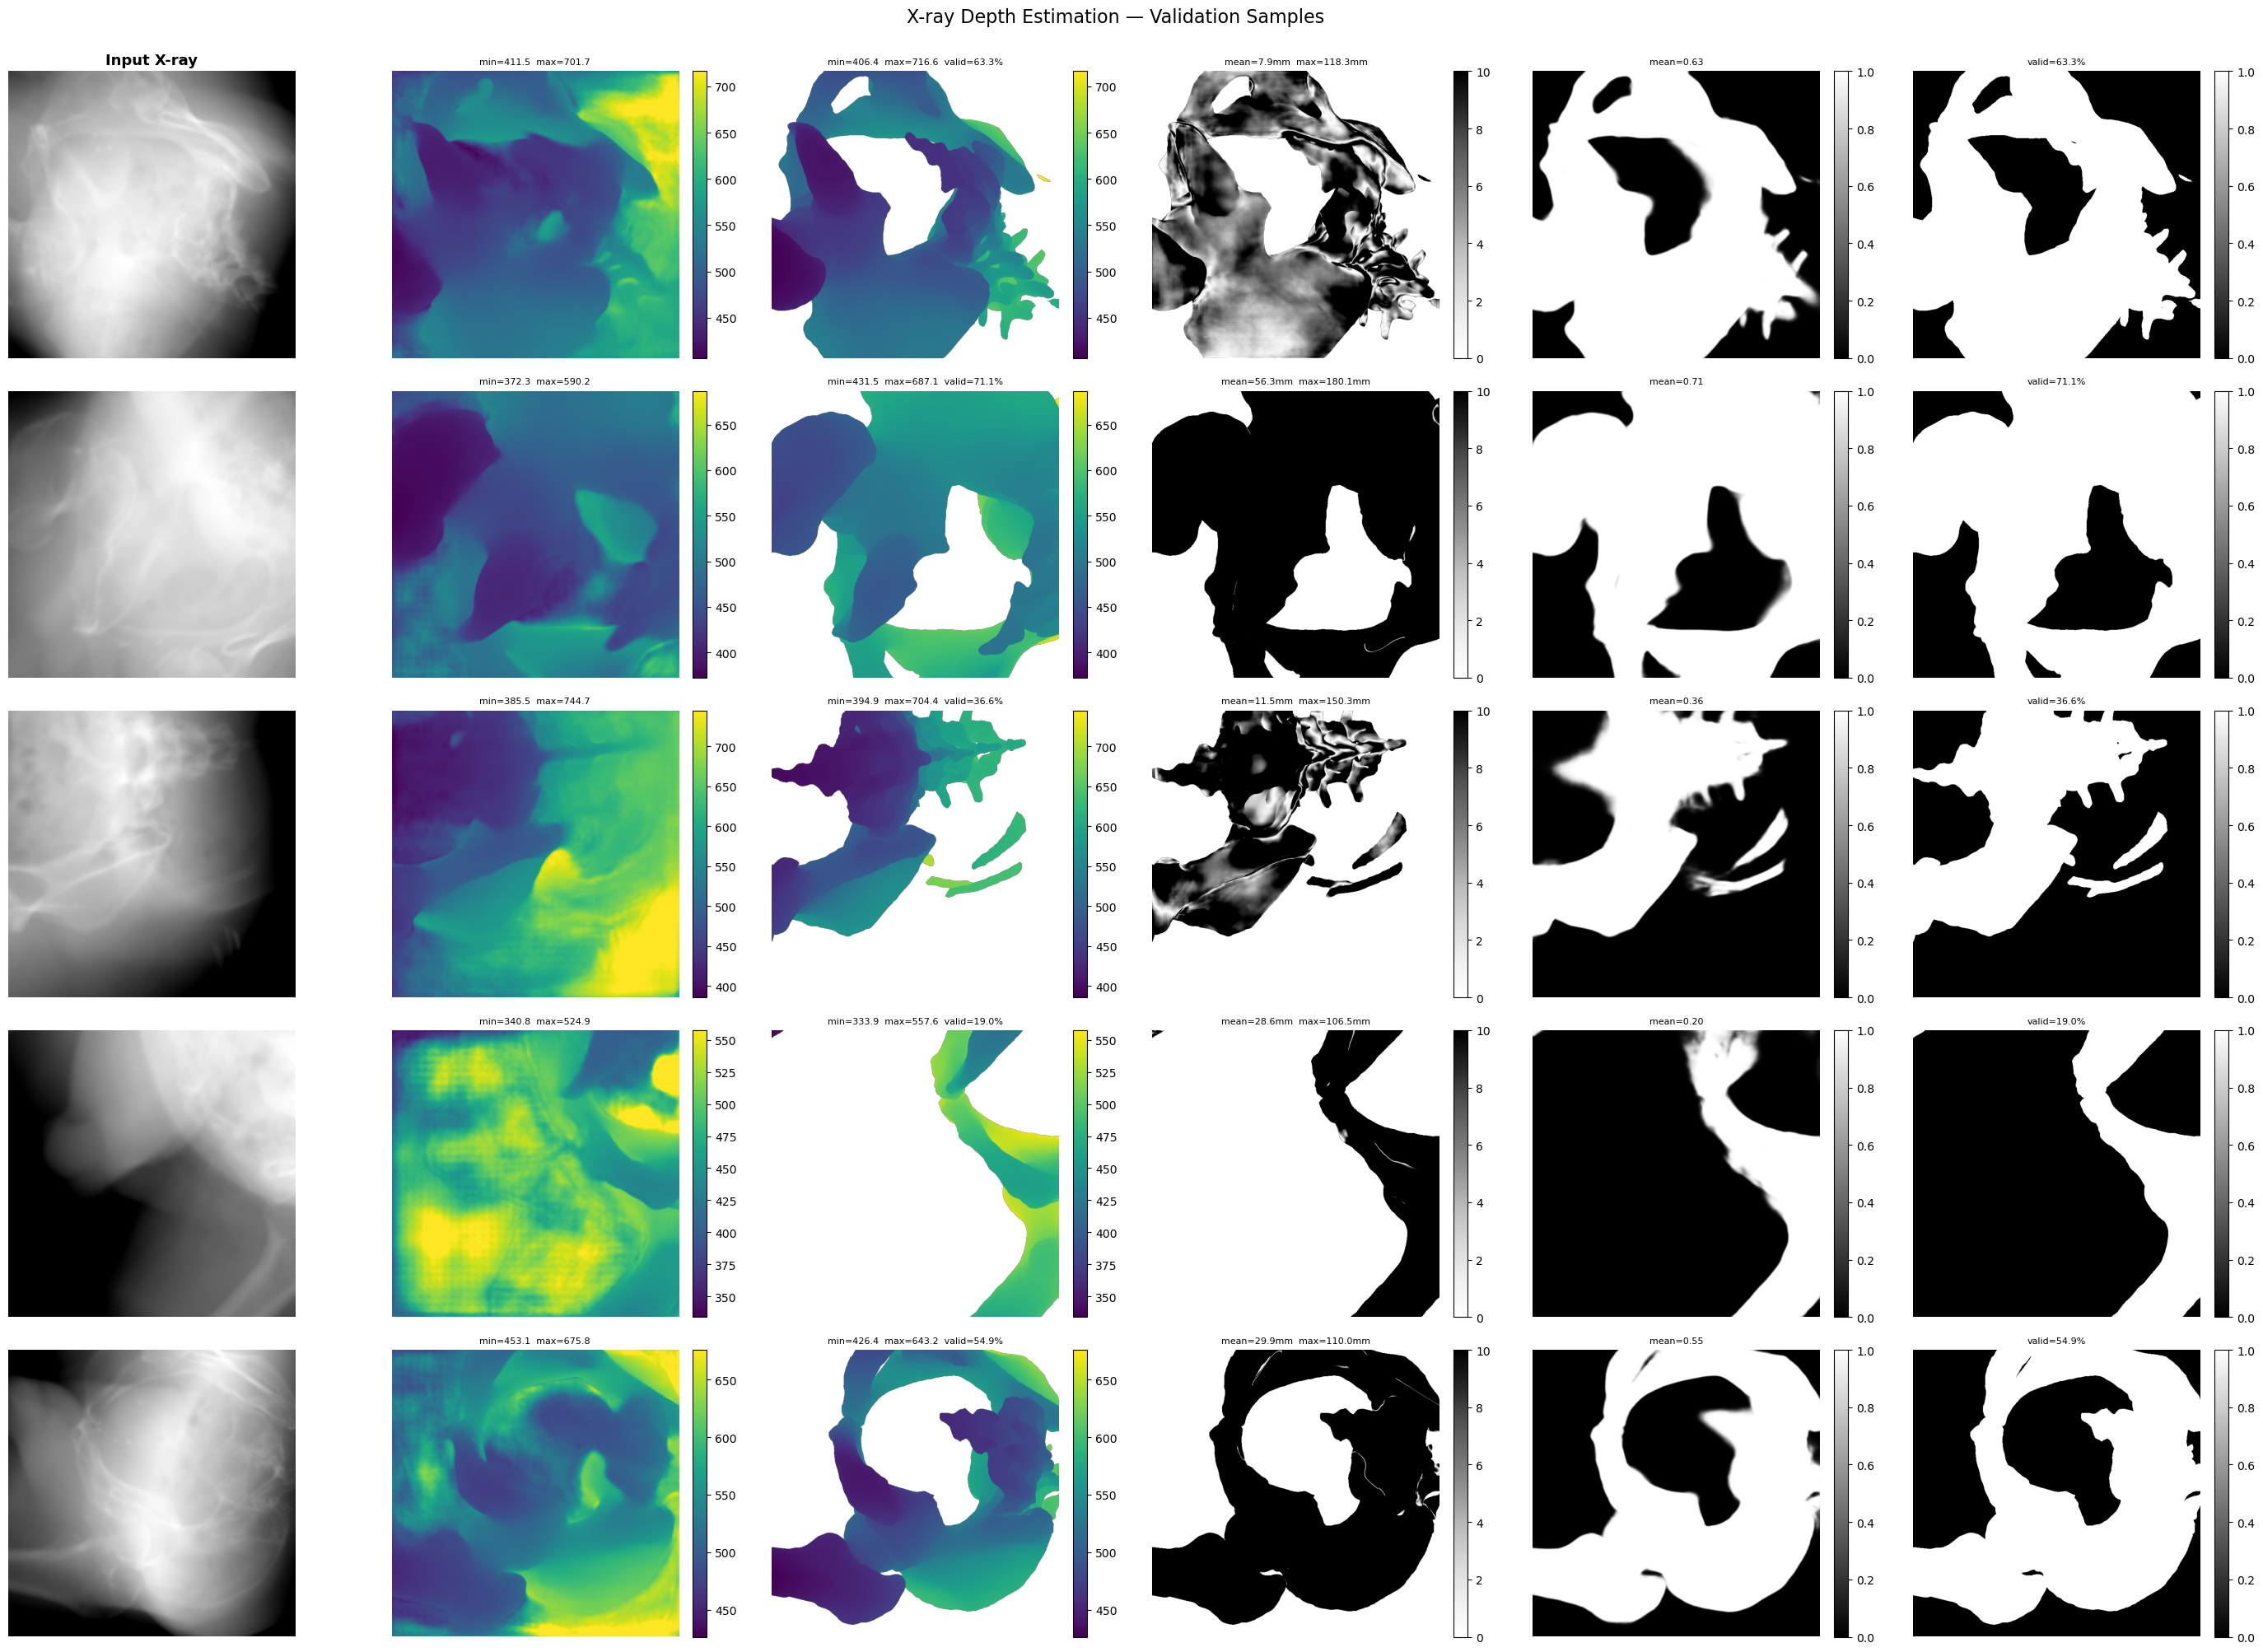


Saved to eval_examples.png


In [6]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.transforms import Compose
import os
import random

from depth_anything_v2.dpt import DepthAnythingV2
from dataset.transform import Resize, NormalizeImage, PrepareForNet

# ── Config ────────────────────────────────────────────────────────────────────
ENCODER        = "vitl"
# CHECKPOINT     = "../checkpoints/metric-finetune/13.pth"
CHECKPOINT     = "exp/xray-0306/latest.pth"
IMAGE_DIR      = "/home/jeremy/data/XrayDepthEstScaling/images"
DEPTH_DIR      = "/home/jeremy/data/XrayDepthEstScaling/depths"
VAL_SPLIT      = "dataset/splits/xray/val.txt"
MAX_DEPTH      = 1000.0
IMG_SIZE       = 518
N_SAMPLES      = 5      # how many val samples to display; set to None to show all
SAVE_PATH      = "eval_examples.png"
SEED           = 42

model_configs = {
    "vits": {"encoder": "vits", "features": 64,  "out_channels": [48, 96, 192, 384]},
    "vitb": {"encoder": "vitb", "features": 128, "out_channels": [96, 192, 384, 768]},
    "vitl": {"encoder": "vitl", "features": 256, "out_channels": [256, 512, 1024, 1024]},
}

# ── Model ─────────────────────────────────────────────────────────────────────
model = DepthAnythingV2(**{**model_configs[ENCODER], "max_depth": MAX_DEPTH, "predict_mask": True})

if os.path.exists(CHECKPOINT):
    print(f"Loading checkpoint from {CHECKPOINT}...")
    checkpoint = torch.load(CHECKPOINT, map_location="cpu")
    model.load_state_dict(checkpoint["model"])
    print(f"Loaded epoch {checkpoint.get('epoch', '?')} | best metrics: {checkpoint.get('previous_best', 'N/A')}")
else:
    print(f"Warning: checkpoint not found at {CHECKPOINT}. Proceeding with random weights.")

model = model.cuda().eval()

# ── Transform ─────────────────────────────────────────────────────────────────
transform = Compose([
    Resize(
        width=IMG_SIZE,
        height=IMG_SIZE,
        resize_target=False,
        keep_aspect_ratio=True,
        ensure_multiple_of=14,
        resize_method="lower_bound",
        image_interpolation_method=cv2.INTER_CUBIC,
    ),
    NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    PrepareForNet(),
])

# ── Load validation split ─────────────────────────────────────────────────────
with open(VAL_SPLIT) as f:
    val_stems = [line.strip() for line in f if line.strip()]

all_fnames = [s + ".tif" for s in val_stems]

if N_SAMPLES is not None and N_SAMPLES < len(all_fnames):
    random.seed(SEED)
    selected = random.sample(all_fnames, N_SAMPLES)
else:
    selected = all_fnames

print(f"Showing {len(selected)} / {len(all_fnames)} validation samples")

# ── Inference helper ──────────────────────────────────────────────────────────
def predict(image_path):
    raw = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    assert raw is not None, f"Could not read: {image_path}"
    assert raw.dtype == np.float32, f"Expected float32 TIFF, got {raw.dtype}"
    image_3ch = np.stack([raw, raw, raw], axis=-1).astype(np.float32)
    sample = transform({"image": image_3ch, "depth": np.zeros_like(raw)})
    img_tensor = torch.from_numpy(sample["image"]).unsqueeze(0).cuda()
    with torch.no_grad():
        pred, pred_mask = model(img_tensor)
    pred = F.interpolate(
        pred[:, None],
        size=raw.shape,
        mode="bilinear",
        align_corners=True,
    )[0, 0].cpu().numpy()
    pred_mask = F.interpolate(
        pred_mask[:, None],
        size=raw.shape,
        mode="bilinear",
        align_corners=True,
    )[0, 0].cpu().numpy()
    return raw, pred, pred_mask

def load_gt(depth_path):
    gt_raw = cv2.imread(depth_path, cv2.IMREAD_ANYCOLOR | cv2.IMREAD_ANYDEPTH)
    assert gt_raw is not None, f"Could not read: {depth_path}"
    gt = gt_raw.astype(np.float32) / 10.0  # uint16 → millimetres
    valid = (gt > 0) & (gt <= MAX_DEPTH)
    return gt, valid

# ── Plot ──────────────────────────────────────────────────────────────────────
depth_unit = "mm" if MAX_DEPTH > 100 else "m"
fig, axes = plt.subplots(len(selected), 6, figsize=(28, 4 * len(selected)))
fig.suptitle("X-ray Depth Estimation — Validation Samples", fontsize=16, y=1.001)

if len(selected) == 1:
    axes = axes[np.newaxis, :]

col_titles = [
    "Input X-ray",
    f"Predicted Depth ({depth_unit})",
    f"GT Depth ({depth_unit})",
    f"Abs Diff ({depth_unit})",
    "Predicted Mask",
    "GT Valid Mask",
]
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=13, fontweight="bold")

for row, fname in enumerate(selected):
    image_path = os.path.join(IMAGE_DIR, fname)
    depth_path = os.path.join(DEPTH_DIR, fname)

    raw_image, pred, pred_mask = predict(image_path)
    gt_depth, valid = load_gt(depth_path)

    pred_valid_min = pred[valid].min() if valid.any() else pred.min()
    pred_valid_max = pred[valid].max() if valid.any() else pred.max()
    vmin = min(pred_valid_min, gt_depth[valid].min() if valid.any() else pred_valid_min)
    vmax = max(pred_valid_max, gt_depth[valid].max() if valid.any() else pred_valid_max)

    # Col 0: input image
    axes[row, 0].imshow(raw_image, cmap="gray", vmin=0, vmax=1)
    axes[row, 0].set_ylabel(fname, fontsize=7, rotation=0, labelpad=120, va="center")
    axes[row, 0].axis("off")

    # Col 1: prediction
    pred_min = pred[valid].min() if valid.any() else 0
    pred_max = pred[valid].max() if valid.any() else 0
    im1 = axes[row, 1].imshow(pred, cmap="viridis", vmin=vmin, vmax=vmax)
    axes[row, 1].set_title(f"min={pred_min:.1f}  max={pred_max:.1f}", fontsize=8)
    axes[row, 1].axis("off")
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046, pad=0.04)

    # Col 2: GT depth
    gt_vis = np.where(valid, gt_depth, np.nan)
    im2 = axes[row, 2].imshow(gt_vis, cmap="viridis", vmin=vmin, vmax=vmax)
    gt_min = gt_depth[valid].min() if valid.any() else 0
    gt_max = gt_depth[valid].max() if valid.any() else 0
    axes[row, 2].set_title(f"min={gt_min:.1f}  max={gt_max:.1f}  valid={valid.mean()*100:.1f}%", fontsize=8)
    axes[row, 2].axis("off")
    plt.colorbar(im2, ax=axes[row, 2], fraction=0.046, pad=0.04)

    # Col 3: absolute difference
    abs_diff = np.where(valid, np.abs(pred - gt_depth), np.nan)
    abs_mean = np.nanmean(abs_diff)
    abs_max  = np.nanmax(abs_diff)
    im3 = axes[row, 3].imshow(abs_diff, cmap="Greys", vmin=0, vmax=10)
    axes[row, 3].set_title(f"mean={abs_mean:.1f}{depth_unit}  max={abs_max:.1f}{depth_unit}", fontsize=8)
    axes[row, 3].axis("off")
    plt.colorbar(im3, ax=axes[row, 3], fraction=0.046, pad=0.04)

    # Col 4: predicted mask
    im4 = axes[row, 4].imshow(pred_mask, cmap="gray", vmin=0, vmax=1)
    axes[row, 4].set_title(f"mean={pred_mask.mean():.2f}", fontsize=8)
    axes[row, 4].axis("off")
    plt.colorbar(im4, ax=axes[row, 4], fraction=0.046, pad=0.04)

    # Col 5: GT valid mask
    im5 = axes[row, 5].imshow(valid.astype(np.float32), cmap="gray", vmin=0, vmax=1)
    axes[row, 5].set_title(f"valid={valid.mean()*100:.1f}%", fontsize=8)
    axes[row, 5].axis("off")
    plt.colorbar(im5, ax=axes[row, 5], fraction=0.046, pad=0.04)

    print(f"[{row+1}/{len(selected)}] {fname} — pred [{pred_min:.1f}, {pred_max:.1f}] | "
          f"gt [{gt_min:.1f}, {gt_max:.1f}] | abs_err mean={abs_mean:.1f}{depth_unit}")

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=120, bbox_inches="tight")
plt.show()
print(f"\nSaved to {SAVE_PATH}")

2. Evaluation without Mask Decoder
## Single Image Check